In [1]:
# Install dependencies if you restarted the runtime
!apt-get install -y swig ffmpeg xvfb
!pip install gymnasium[box2d] stable-baselines3 shimmy pyvirtualdisplay sb3-contrib

import gymnasium as gym
import os
import torch
import numpy as np
import base64
from datetime import datetime
from sb3_contrib import TQC
from stable_baselines3.common.vec_env import SubprocVecEnv, VecNormalize, VecVideoRecorder, DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.utils import set_random_seed
from google.colab import drive
from pyvirtualdisplay import Display
from IPython.display import HTML, display as ipy_display
from typing import Callable

# --- COLAB SETUP ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

try:
    virtual_display
except NameError:
    virtual_display = Display(visible=0, size=(1400, 900))
    virtual_display.start()

# --- CONFIGURATION ---
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# --- EXPERIMENT NAME ---
# Labeled for "No Normalization"
EXPERIMENT_NAME = f"tqc_v3_ablation_no_norm_3M_{timestamp}"

ENV_ID = "BipedalWalkerHardcore-v3"
TOTAL_TIMESTEPS = 3_000_000
SEED = 42
NUM_CPU = 4

# --- DIRECTORY SETUP ---
base_path = "/content/drive/MyDrive/aisf_project"
log_dir = f"{base_path}/logs/{EXPERIMENT_NAME}"
model_dir = f"{base_path}/models/{EXPERIMENT_NAME}"
video_dir = f"{base_path}/videos/{EXPERIMENT_NAME}"

os.makedirs(log_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)
os.makedirs(video_dir, exist_ok=True)

print(f"Logging to: {log_dir}")
print(f"Running Ablation: NO NORMALIZATION (VecNormalize disabled)")

# --- LINEAR SCHEDULE ---
def linear_schedule(initial_value: float) -> Callable[[float], float]:
    def func(progress_remaining: float) -> float:
        return progress_remaining * initial_value
    return func

# --- ENVIRONMENT MAKER ---
def make_env(rank: int, seed: int = 0):
    def _init():
        env = gym.make(ENV_ID, render_mode="rgb_array")
        env = Monitor(env, os.path.join(log_dir, str(rank)))
        env.reset(seed=seed + rank)
        return env
    return _init

def train():
    print(f"--- Starting Training: {EXPERIMENT_NAME} ---")

    # 1. PARALLEL ENVIRONMENTS
    env = SubprocVecEnv([make_env(i, SEED) for i in range(NUM_CPU)])

    # --- CHANGE 1: DISABLED NORMALIZATION ---
    # env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10.)

    # Eval Env
    eval_env = SubprocVecEnv([make_env(999, SEED)])

    # --- CHANGE 2: DISABLED NORMALIZATION FOR EVAL ---
    # eval_env = VecNormalize(eval_env, norm_obs=True, norm_reward=False, clip_obs=10.)

    eval_env.training = False

    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=model_dir,
        log_path=log_dir,
        eval_freq=50_000,
        deterministic=True,
        render=False
    )

    # --- TQC CONFIGURATION (Standard) ---
    policy_kwargs = dict(
        n_critics=2,
        n_quantiles=25,
        net_arch=[400, 300],
    )

    model = TQC(
        "MlpPolicy",
        env,
        top_quantiles_to_drop_per_net=2, # Truncation kept active
        verbose=1,
        seed=SEED,
        tensorboard_log=log_dir,
        policy_kwargs=policy_kwargs,
        learning_rate=linear_schedule(7.3e-4),
        buffer_size=1_000_000,
        batch_size=256,
        gamma=0.99,
        tau=0.01,
        train_freq=64,
        gradient_steps=64,
        learning_starts=10_000,
        use_sde=False
    )

    model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=eval_callback, log_interval=100)

    model.save(f"{model_dir}/final_model")

    # --- CHANGE 3: DO NOT SAVE VECNORMALIZE STATS ---
    # env.save(f"{model_dir}/vec_normalize.pkl")

    print("Training finished.")
    env.close()

def record_and_show_video():
    print(f"--- Recording Video for {EXPERIMENT_NAME} ---")

    best_model_path = os.path.join(model_dir, "best_model.zip")
    stats_path = os.path.join(model_dir, "vec_normalize.pkl")

    if not os.path.exists(best_model_path):
        best_model_path = os.path.join(model_dir, "final_model.zip")

    env = DummyVecEnv([make_env(1000, SEED)])

    # Only load stats if they exist (They won't for this run)
    if os.path.exists(stats_path):
        print("Loading normalization stats...")
        env = VecNormalize.load(stats_path, env)
        env.training = False
        env.norm_reward = False
    else:
        print("Note: No normalization stats found (Expected for this ablation).")

    model = TQC.load(best_model_path)

    video_env = VecVideoRecorder(
        env,
        video_dir,
        record_video_trigger=lambda x: x == 0,
        video_length=2000,
        name_prefix=f"{EXPERIMENT_NAME}_agent"
    )

    obs = video_env.reset()
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _ = video_env.step(action)
        if isinstance(done, (list, np.ndarray)):
             done = done[0]

    video_env.close()

    mp4_list = [f for f in os.listdir(video_dir) if f.endswith('.mp4')]
    if mp4_list:
        mp4 = os.path.join(video_dir, mp4_list[0])
        video_data = open(mp4, "rb").read()
        b64 = base64.b64encode(video_data)
        ipy_display(HTML(f'''
        <video width="600" controls autoplay loop>
            <source src="data:video/mp4;base64,{b64.decode()}" type="video/mp4">
        </video>
        '''))
    else:
        print("Could not find video file.")

if __name__ == "__main__":
    train()
    record_and_show_video()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.16).
The following additional packages will be installed:
  swig4.0
Suggested packages:
  swig-doc swig-examples swig4.0-examples swig4.0-doc
The following NEW packages will be installed:
  swig swig4.0
0 upgraded, 2 newly installed, 0 to remove and 41 not upgraded.
Need to get 1,116 kB of archives.
After this operation, 5,542 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig4.0 amd64 4.0.2-1ubuntu1 [1,110 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig all 4.0.2-1ubuntu1 [5,632 B]
Fetched 1,116 kB in 0s (9,359 kB/s)
Selecting previously unselected package swig4.0.
(Reading database ... 121689 files and directories currently installed.)
Preparing to unpack .../swig4.0_4.0.2-1ubuntu1_amd64.

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Logging to: /content/drive/MyDrive/aisf_project/logs/tqc_v3_ablation_no_norm_3M_20251228_1510
Running Ablation: NO NORMALIZATION (VecNormalize disabled)
--- Starting Training: tqc_v3_ablation_no_norm_3M_20251228_1510 ---
Using cuda device
Logging to /content/drive/MyDrive/aisf_project/logs/tqc_v3_ablation_no_norm_3M_20251228_1510/TQC_1


...

Note: No normalization stats found (Expected for this ablation).
Saving video to /content/drive/MyDrive/aisf_project/videos/tqc_v3_ablation_no_norm_3M_20251228_1510/tqc_v3_ablation_no_norm_3M_20251228_1510_agent-step-0-to-step-2000.mp4


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


Moviepy - Building video /content/drive/MyDrive/aisf_project/videos/tqc_v3_ablation_no_norm_3M_20251228_1510/tqc_v3_ablation_no_norm_3M_20251228_1510_agent-step-0-to-step-2000.mp4.
Moviepy - Writing video /content/drive/MyDrive/aisf_project/videos/tqc_v3_ablation_no_norm_3M_20251228_1510/tqc_v3_ablation_no_norm_3M_20251228_1510_agent-step-0-to-step-2000.mp4



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Moviepy - Done !
Moviepy - video ready /content/drive/MyDrive/aisf_project/videos/tqc_v3_ablation_no_norm_3M_20251228_1510/tqc_v3_ablation_no_norm_3M_20251228_1510_agent-step-0-to-step-2000.mp4


In [2]:
# Install dependencies if you restarted the runtime
!apt-get install -y swig ffmpeg xvfb
!pip install gymnasium[box2d] stable-baselines3 shimmy pyvirtualdisplay sb3-contrib

import gymnasium as gym
import os
import torch
import numpy as np
import base64
from datetime import datetime
from sb3_contrib import TQC
from stable_baselines3.common.vec_env import SubprocVecEnv, VecNormalize, VecVideoRecorder, DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.utils import set_random_seed
from google.colab import drive
from pyvirtualdisplay import Display
from IPython.display import HTML, display as ipy_display
from typing import Callable

# --- COLAB SETUP ---
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

try:
    virtual_display
except NameError:
    virtual_display = Display(visible=0, size=(1400, 900))
    virtual_display.start()

# --- CONFIGURATION ---
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# --- EXPERIMENT NAME ---
EXPERIMENT_NAME = f"tqc_v3_ablation_tiny_net_{timestamp}"

ENV_ID = "BipedalWalkerHardcore-v3"
TOTAL_TIMESTEPS = 3_000_000
SEED = 42
NUM_CPU = 4

# --- DIRECTORY SETUP ---
base_path = "/content/drive/MyDrive/aisf_project"
log_dir = f"{base_path}/logs/{EXPERIMENT_NAME}"
model_dir = f"{base_path}/models/{EXPERIMENT_NAME}"
video_dir = f"{base_path}/videos/{EXPERIMENT_NAME}"

os.makedirs(log_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)
os.makedirs(video_dir, exist_ok=True)

print(f"Logging to: {log_dir}")
print(f"Running Ablation: TINY NETWORK [64, 64]")

# --- LINEAR SCHEDULE ---
def linear_schedule(initial_value: float) -> Callable[[float], float]:
    def func(progress_remaining: float) -> float:
        return progress_remaining * initial_value
    return func

# --- ENVIRONMENT MAKER ---
def make_env(rank: int, seed: int = 0):
    def _init():
        env = gym.make(ENV_ID, render_mode="rgb_array")
        env = Monitor(env, os.path.join(log_dir, str(rank)))
        env.reset(seed=seed + rank)
        return env
    return _init

def train():
    print(f"--- Starting Training: {EXPERIMENT_NAME} ---")

    # 1. PARALLEL ENVIRONMENTS
    env = SubprocVecEnv([make_env(i, SEED) for i in range(NUM_CPU)])

    # 2. NORMALIZATION (Active)
    env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10.)

    # Eval Env
    eval_env = SubprocVecEnv([make_env(999, SEED)])
    eval_env = VecNormalize(eval_env, norm_obs=True, norm_reward=False, clip_obs=10.)
    eval_env.training = False

    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=model_dir,
        log_path=log_dir,
        eval_freq=50_000,
        deterministic=True,
        render=False
    )

    # --- TQC CONFIGURATION ---
    policy_kwargs = dict(
        n_critics=2,
        n_quantiles=25,
        # --- CHANGE 1: TINY ARCHITECTURE ---
        # Reducing capacity from [400, 300] to [64, 64]
        net_arch=[64, 64],
    )

    model = TQC(
        "MlpPolicy",
        env,
        top_quantiles_to_drop_per_net=2,
        verbose=1,
        seed=SEED,
        tensorboard_log=log_dir,
        policy_kwargs=policy_kwargs,
        learning_rate=linear_schedule(7.3e-4),
        buffer_size=1_000_000,
        batch_size=256,
        gamma=0.99,
        tau=0.01,
        train_freq=64,
        gradient_steps=64,
        learning_starts=10_000,
        use_sde=False
    )

    model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=eval_callback, log_interval=100)

    model.save(f"{model_dir}/final_model")
    env.save(f"{model_dir}/vec_normalize.pkl")
    print("Training finished.")
    env.close()

def record_and_show_video():
    print(f"--- Recording Video for {EXPERIMENT_NAME} ---")

    best_model_path = os.path.join(model_dir, "best_model.zip")
    stats_path = os.path.join(model_dir, "vec_normalize.pkl")

    if not os.path.exists(best_model_path):
        best_model_path = os.path.join(model_dir, "final_model.zip")

    env = DummyVecEnv([make_env(1000, SEED)])

    if os.path.exists(stats_path):
        env = VecNormalize.load(stats_path, env)
        env.training = False
        env.norm_reward = False
    else:
        print("Warning: Normalization stats not found!")

    model = TQC.load(best_model_path)

    video_env = VecVideoRecorder(
        env,
        video_dir,
        record_video_trigger=lambda x: x == 0,
        video_length=2000,
        name_prefix=f"{EXPERIMENT_NAME}_agent"
    )

    obs = video_env.reset()
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _ = video_env.step(action)
        if isinstance(done, (list, np.ndarray)):
             done = done[0]

    video_env.close()

    mp4_list = [f for f in os.listdir(video_dir) if f.endswith('.mp4')]
    if mp4_list:
        mp4 = os.path.join(video_dir, mp4_list[0])
        video_data = open(mp4, "rb").read()
        b64 = base64.b64encode(video_data)
        ipy_display(HTML(f'''
        <video width="600" controls autoplay loop>
            <source src="data:video/mp4;base64,{b64.decode()}" type="video/mp4">
        </video>
        '''))
    else:
        print("Could not find video file.")

if __name__ == "__main__":
    train()
    record_and_show_video()

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
swig is already the newest version (4.0.2-1ubuntu1).
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.16).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
Logging to: /content/drive/MyDrive/aisf_project/logs/tqc_v3_ablation_tiny_net_20251228_1749
Running Ablation: TINY NETWORK [64, 64]
--- Starting Training: tqc_v3_ablation_tiny_net_20251228_1749 ---
Using cuda device
Logging to /content/drive/MyDrive/aisf_project/logs/tqc_v3_ablation_tiny_net_20251228_1749/TQC_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 611      |
|    ep_rew_mean     | -122     |
| time/              |          |
|    episodes        | 100      |
|    fps             | 367      |
|    time_elapsed    | 167      |
|    total_timesteps | 61608    |
| train/             |          |
|

Moviepy - Done !
Moviepy - video ready /content/drive/MyDrive/aisf_project/videos/tqc_v3_ablation_tiny_net_20251228_1749/tqc_v3_ablation_tiny_net_20251228_1749_agent-step-0-to-step-2000.mp4


--- LOADING DATA ---

--- GENERATING GRAPH ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Graph saved to: /content/drive/MyDrive/aisf_project/logs/graph_tqc_tiny_net_ablation_pro.png


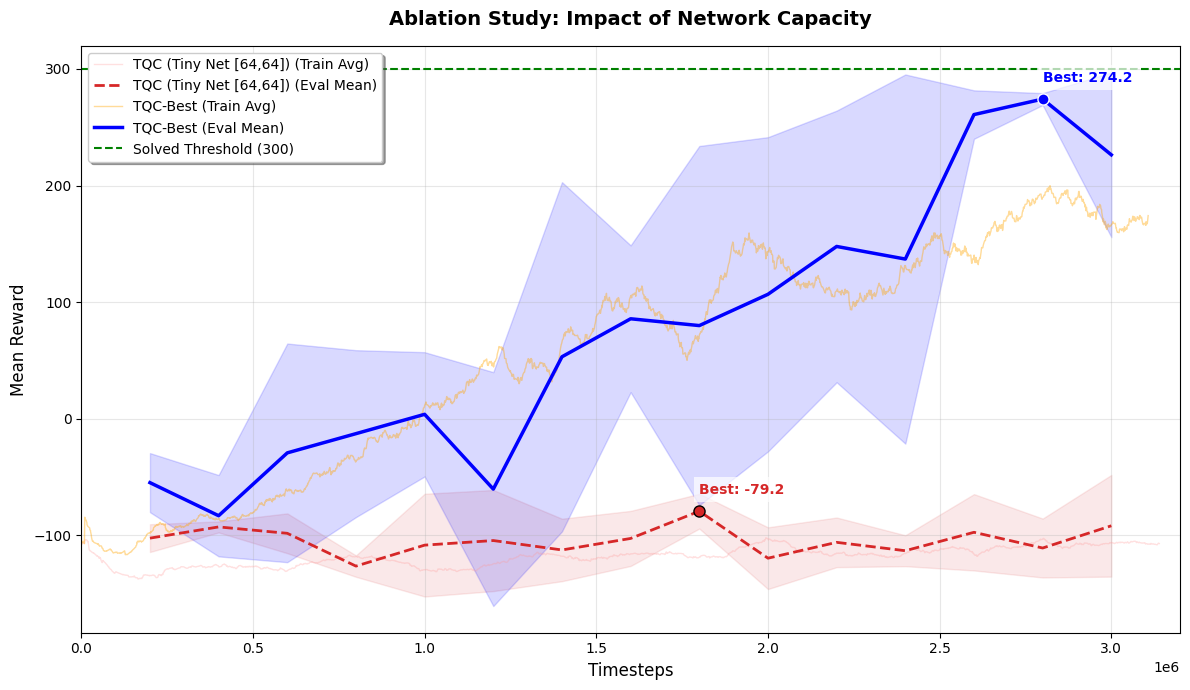

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import glob

# --- CONFIGURATION ---
BASE_PATH = "/content/drive/MyDrive/aisf_project/logs"

# CORRECT FOLDER NAMES
# Baseline: Original successful run (0-3M steps)
EXP_BASELINE = "tqc_v3_hardcore_rerun_20251227_1928"
# Ablation: Tiny Network (From your screenshot)
EXP_ABLATION = "tqc_v3_ablation_tiny_net_20251228_1749"

# --- DATA LOADING FUNCTION ---
def load_experiment_data(exp_name):
    full_path = os.path.join(BASE_PATH, exp_name)
    data = {}

    # 1. LOAD TRAINING DATA (Orange/Pink Lines)
    monitor_files = glob.glob(os.path.join(full_path, "**", "*monitor.csv"), recursive=True)

    if monitor_files:
        df_list = []
        for f in monitor_files:
            try:
                if os.path.getsize(f) > 0:
                    df = pd.read_csv(f, skiprows=1)
                    # Force numeric
                    for col in ['r', 'l', 't']:
                        if col in df.columns:
                            df[col] = pd.to_numeric(df[col], errors='coerce')
                    df = df.dropna(subset=['r', 'l'])
                    if not df.empty:
                        df_list.append(df)
            except: continue

        if df_list:
            train_df = pd.concat(df_list, ignore_index=True)
            if 't' in train_df.columns:
                train_df = train_df.sort_values(by='t')

            train_df['l_cumsum'] = train_df['l'].cumsum()
            train_df['rolling_reward'] = train_df['r'].rolling(window=100, min_periods=1).mean()

            # Cap at 3.2M
            data['train'] = train_df[train_df['l_cumsum'] <= 3200000]
        else:
            data['train'] = None
    else:
        data['train'] = None

    # 2. LOAD EVALUATION DATA (Blue/Red Lines)
    eval_files = glob.glob(os.path.join(full_path, "**", "evaluations.npz"), recursive=True)

    if eval_files:
        try:
            eval_data = np.load(eval_files[0])
            data['eval_timesteps'] = eval_data['timesteps']
            data['eval_mean'] = np.mean(eval_data['results'], axis=1)
            data['eval_std'] = np.std(eval_data['results'], axis=1)
        except:
            data['eval_timesteps'] = None
    else:
        data['eval_timesteps'] = None

    return data

# --- PLOTTING FUNCTION ---
def plot_pro_comparison(base_data, abl_data, base_name, abl_name, title):
    plt.figure(figsize=(12, 7))

    # --- PLOT ABLATION (Red) ---
    if abl_data['train'] is not None:
        plt.plot(abl_data['train']['l_cumsum'], abl_data['train']['rolling_reward'],
                 color='#ff9999', alpha=0.3, linewidth=1, label=f"{abl_name} (Train Avg)")

    if abl_data['eval_timesteps'] is not None:
        plt.plot(abl_data['eval_timesteps'], abl_data['eval_mean'],
                 color='#d62728', linewidth=2, linestyle='--', label=f"{abl_name} (Eval Mean)")
        plt.fill_between(abl_data['eval_timesteps'],
                         abl_data['eval_mean'] - abl_data['eval_std'],
                         abl_data['eval_mean'] + abl_data['eval_std'],
                         color='#d62728', alpha=0.1)

        # Pinpoint Ablation Best
        best_abl_idx = np.argmax(abl_data['eval_mean'])
        best_abl_x = abl_data['eval_timesteps'][best_abl_idx]
        best_abl_y = abl_data['eval_mean'][best_abl_idx]

        plt.plot(best_abl_x, best_abl_y, 'o', color='#d62728', markersize=8, markeredgecolor='black')
        plt.annotate(f"Best: {best_abl_y:.1f}",
                     xy=(best_abl_x, best_abl_y),
                     xytext=(best_abl_x, best_abl_y + 15),
                     color='#d62728', fontweight='bold', fontsize=10,
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

    # --- PLOT BASELINE (Blue) ---
    if base_data['train'] is not None:
        plt.plot(base_data['train']['l_cumsum'], base_data['train']['rolling_reward'],
                 color='orange', alpha=0.4, linewidth=1, label=f"{base_name} (Train Avg)")

    if base_data['eval_timesteps'] is not None:
        plt.plot(base_data['eval_timesteps'], base_data['eval_mean'],
                 color='blue', linewidth=2.5, label=f"{base_name} (Eval Mean)")
        plt.fill_between(base_data['eval_timesteps'],
                         base_data['eval_mean'] - base_data['eval_std'],
                         base_data['eval_mean'] + base_data['eval_std'],
                         color='blue', alpha=0.15)

        # Pinpoint Baseline Best
        best_base_idx = np.argmax(base_data['eval_mean'])
        best_base_x = base_data['eval_timesteps'][best_base_idx]
        best_base_y = base_data['eval_mean'][best_base_idx]

        plt.plot(best_base_x, best_base_y, 'o', color='blue', markersize=8, markeredgecolor='white')
        plt.annotate(f"Best: {best_base_y:.1f}",
                     xy=(best_base_x, best_base_y),
                     xytext=(best_base_x, best_base_y + 15),
                     color='blue', fontweight='bold', fontsize=10,
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

    # --- FORMATTING ---
    plt.axhline(y=300, color='green', linestyle='--', linewidth=1.5, label="Solved Threshold (300)")
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Timesteps", fontsize=12)
    plt.ylabel("Mean Reward", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper left', frameon=True, shadow=True)
    plt.xlim(0, 3200000)
    plt.tight_layout()

    save_path = f"{BASE_PATH}/graph_tqc_tiny_net_ablation_pro.png"
    plt.savefig(save_path, dpi=150)
    print(f"Graph saved to: {save_path}")
    plt.show()

# --- MAIN RUN ---
print("--- LOADING DATA ---")
if not os.path.exists(os.path.join(BASE_PATH, EXP_BASELINE)):
    print(f"ERROR: Could not find baseline folder: {EXP_BASELINE}")
else:
    baseline_data = load_experiment_data(EXP_BASELINE)
    ablation_data = load_experiment_data(EXP_ABLATION)

    print("\n--- GENERATING GRAPH ---")
    plot_pro_comparison(baseline_data, ablation_data,
                        "TQC-Best", "TQC (Tiny Net [64,64])",
                        "Ablation Study: Impact of Network Capacity")